# Red neuronal en PyTorch

### Autor: Jesús Alejandro Pérez Granados

### Fecha: 5 de marzo de 2026

En esta tarea, aplicamos lo aprendido de redes neuronales aplicado en un contexto real y en programación. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# ── Reproducibilidad ─────────────────────────────────────────
SEED = 9091989
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Dispositivo ──────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"PyTorch version : {torch.__version__}")
print(f"Dispositivo     : {device}")
print("Entorno listo.")

PyTorch version : 2.10.0+cpu
Dispositivo     : cpu
Entorno listo.


__Pregunta 0.1 ¿Por qué fijamos SEED =... al principio y no al final, ni en ningún otro momento? ¿Qué procesos dentro del entrenamiento de una red neuronal son probabilistas y se verían afectados si no hubieras fijado la semilla?__

Se fija desde el inicio porque afecta a la generación de todo lo aleatorio (más bien pseudoaleatorio) del código. Agregarlo más adelante signifcaría una aleatoreidad no controlada desde el inicio. En el entrenaimento, se inicializan pesos diferentes de 0, y la seed hace que estos sean reproducibles (los mismos). También, el *split* de datos en train y test son influenciados por esta seed aleatoria.

__Pregunta 0.2 La celda imprime el dispositivo. La gran mayoría de ustedes verá cpu. ¿Por qué para este problema específico (1,030 muestras, 8 features, red pequeña) eso no es un problema? ¿En qué tipo de problema sí necesitarías GPU?__

Al ser una base de datos relativamente pequeña, la CPU es suficiente para modelar una red con estos datos, y hasta más eficiente que traer la GPU. En problemas con datos masivos o redes de numerosas capas, sí se debería emplear la GPU porque, aunque en pocos datos es un sobreuso de la herramienta, en muchísimos datos es más eficiente que la CPU. 

# Parte 1

## Carga de datos

In [2]:
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases"
       "/concrete/compressive/Concrete_Data.xls")

df = pd.read_excel(url)
df.columns = [
    "cemento", "escoria", "ceniza", "agua",
    "superplast", "agregado_grueso", "agregado_fino",
    "edad", "resistencia"
]

print(f"Dimensiones: {df.shape}")
print(f"\nValores nulos:\n{df.isnull().sum()}")
print(f"\nEstadísticas descriptivas:")
df.describe().round(2)

Dimensiones: (1030, 9)

Valores nulos:
cemento            0
escoria            0
ceniza             0
agua               0
superplast         0
agregado_grueso    0
agregado_fino      0
edad               0
resistencia        0
dtype: int64

Estadísticas descriptivas:


,cemento,escoria,ceniza,agua,superplast,agregado_grueso,agregado_fino,edad,resistencia
count,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00,1030.00
mean,281.17,73.90,54.19,181.57,6.20,972.92,773.58,45.66,35.82
std,104.51,86.28,64.00,21.36,5.97,77.75,80.18,63.17,16.71
min,102.00,0.00,0.00,121.75,0.00,801.00,594.00,1.00,2.33
25%,192.38,0.00,0.00,164.90,0.00,932.00,730.95,7.00,23.71
50%,272.90,22.00,0.00,185.00,6.35,968.00,779.51,28.00,34.44
75%,350.00,142.95,118.27,192.00,10.16,1029.40,824.00,56.00,46.14
max,540.00,359.40,200.10,247.00,32.20,1145.00,992.60,365.00,82.60


__Pregunta 1.1 El dataset tiene 1,030 observaciones. GPT-3 fue entrenado con aproximadamente 300 mil millones de tokens. ¿Qué implica esa diferencia de escala para la elección entre una red neuronal profunda y un modelo lineal? Antes de ver los resultados de esta actividad...qué esperas encontrar?__

Honestamente, debido a la pequeña cantidad de datos, no espero un desempeño mayor al de una regresión, pues son 8 *features* y solo 1000 datos. Espero encontrar algo que tenga cierta funcionalidad, pero no sea muy preciso y será un modelo sobrecomplicado para la cantidad de datos

## Exploración Visual

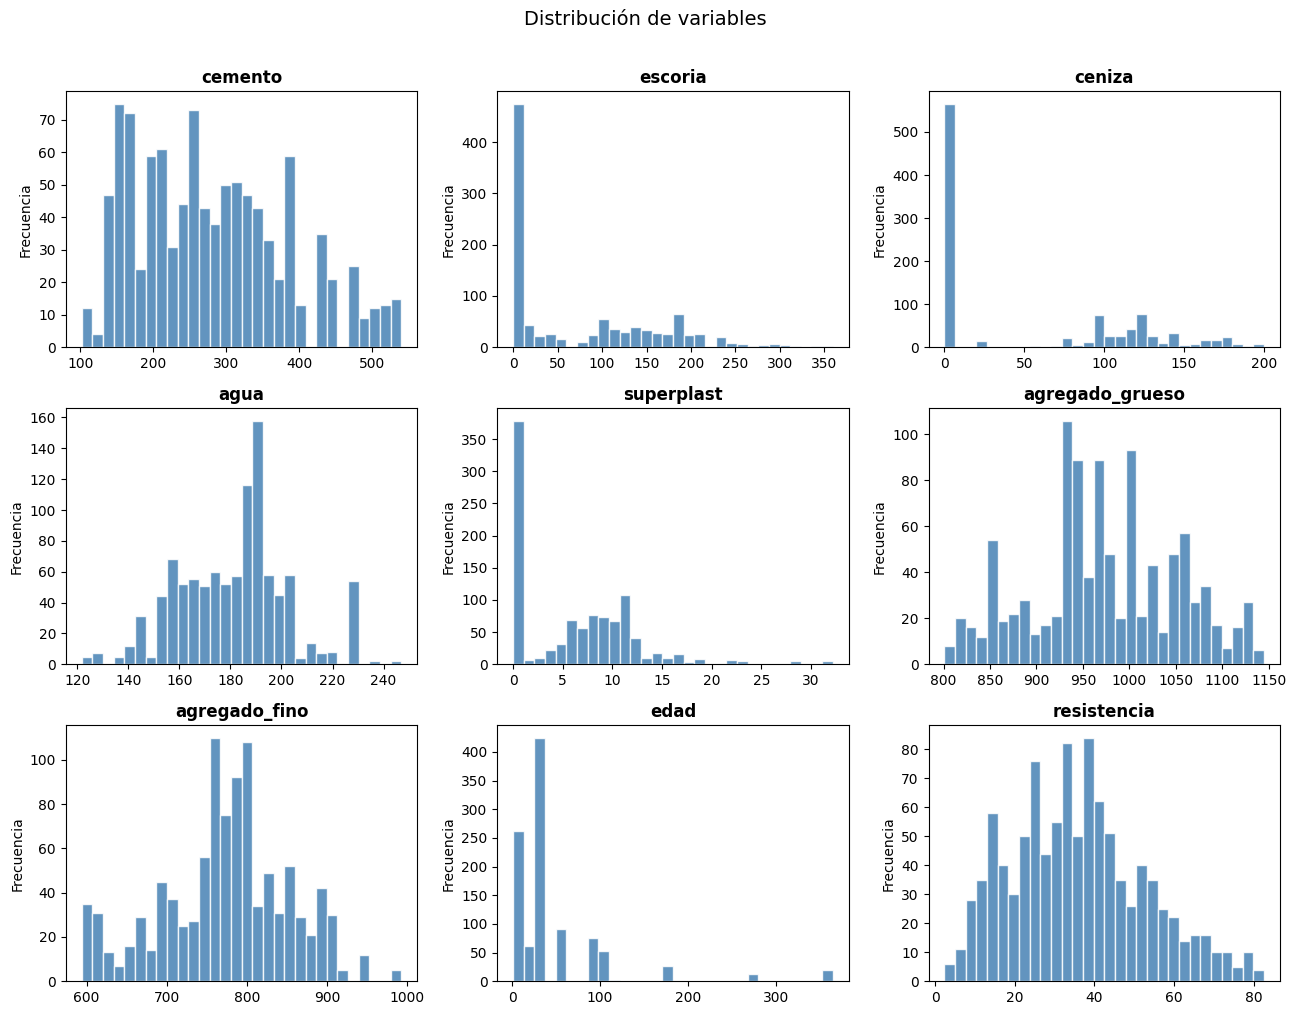

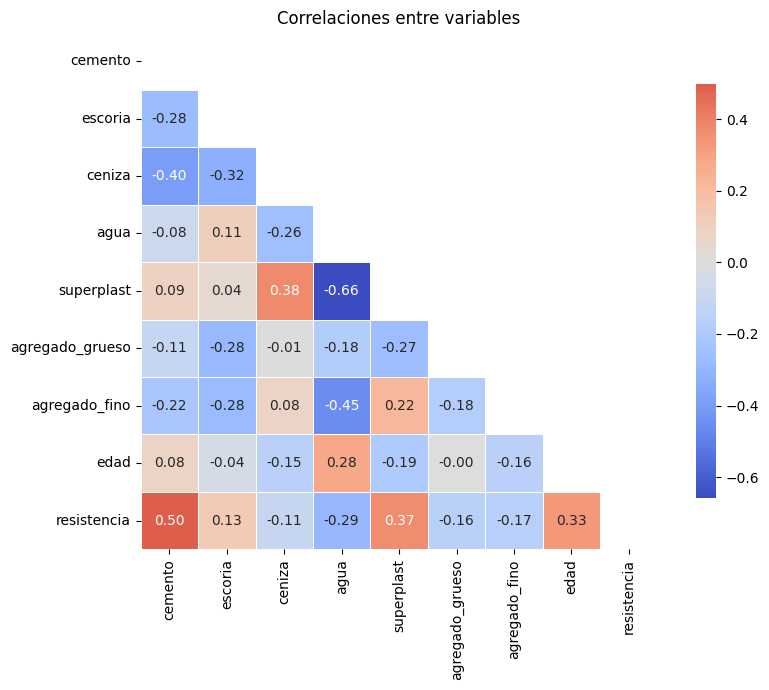

In [3]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontweight="bold")
    axes[i].set_ylabel("Frecuencia")

plt.suptitle("Distribución de variables", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Mapa de correlación
plt.figure(figsize=(9, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlaciones entre variables")
plt.tight_layout()
plt.show()

__Pregunta 1.2 Observa el histograma de edad. Describe su distribución. ¿Es aproximadamente normal? ¿Por qué importa la distribución de las variables de entrada antes de pasarlas a una red neuronal?__

La distribución de la edad no es para nada cercano a lo normal. La mayoría de los datos se concentran en el extremo izquierdo. Esto afecta porque puede ocasionar sesgo de clases y mala generalización en la red neuronal.

__Pregunta 1.3 Mira el mapa de correlaciones. ¿Cuál variable tiene mayor correlación con resistencia? ¿Eso significa que una red neuronal sólo necesitaría esa variable para predecir bien?__

La variable con mayor correlación es cemento. Igualmente se deben utilizar más variables, pues utilizar una con 0.5 de correlación no sería suficiente. El cemento es compuesto por diferentes partes y, junto con otros factores, estos influyen en la resistencia. Además, convertiría la red en una regresion lineal simple básicamente.

## División y Escalado

In [4]:
X = df.drop("resistencia", axis=1).values   # shape: (1030, 8)
y = df["resistencia"].values.reshape(-1, 1) # shape: (1030, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=SEED
)

print(f"Train : {X_train.shape[0]} muestras")
print(f"Val   : {X_val.shape[0]} muestras")
print(f"Test  : {X_test.shape[0]} muestras")

# Escalado
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

y_train_sc = scaler_y.fit_transform(y_train)
y_val_sc   = scaler_y.transform(y_val)
y_test_sc  = scaler_y.transform(y_test)

Train : 700 muestras
Val   : 124 muestras
Test  : 206 muestras


__Pregunta 1.4 Esta vez hay tres conjuntos: train, val y test. ¿Cuál es la función específica del conjunto de validación que no puede cumplir el conjunto de prueba? Si usaras el test set para early stopping, ¿qué error conceptual estarías cometiendo?__

El conjunto de validación aprenta ser como otro test, pero este es utilizado para terminar el entrenamiento correctamente. Es como una prueba antes de la prueba final que sí ajusta el modelo (busca verificar su desempeño en datos nuevos y optimizar). Ya el test solamente se utiliza para probar el modelo, no lo reajusta. Si usaras el test para ajustarlo, estarías cometiendo Data Leakage, pues permites información que no debería de tener de sus datos nuevos dentro del modelo.

__Pregunta 1.5 X_val_sc y X_test_sc usan .transform(), no .fit_transform(). Explica por qué esto es importante en términos de lo que el modelo "puede saber" sobre los datos. ¿Qué nombre tiene este tipo de error cuando se comete?__

El .fit_trsansform() se utiliza en el entranmiento porque utiliza esos datos para la transformación de los mismos. Los otros dos utilizan solamente transform() porque se hacen con base en los datos de entrenamiento, ya que hacerlo con base en ellos mismo sería, de nuevo, dar información extra (al modelo) al momento de probar esos datos, cuando debería funcionar con base en pura información del entrenamiento. Esto sería Data Leakage.

__Pregunta 1.6 Estamos escalando también y. Escalar el target no siempre es necesario en regresión lineal, pero en redes neuronales es común. Menciona dos razones técnicas por las que escalar el target puede ayudar al entrenamiento de una red.__

Las redes funcionan con pesos, por lo que mantener un estándar en todas sus variables es importante para evitar que malinterprete la importancia de variables con números distintos (por ejemplo, el 80 en resistencia es bastante y en el agua es muy poco).
Otra razón crucial es dentro de las funciones de activación. Mantener los datos en esa escala también evita errores en ciertas funciones como el sigmoide que va de 0 a 1. También los errores no son sobre-penalizados por la red.

## Conversión a Tensores

In [5]:
def to_tensor(array):
    return torch.tensor(array, dtype=torch.float32).to(device)

X_train_t = to_tensor(X_train_sc)
X_val_t   = to_tensor(X_val_sc)
X_test_t  = to_tensor(X_test_sc)
y_train_t = to_tensor(y_train_sc)
y_val_t   = to_tensor(y_val_sc)
y_test_t  = to_tensor(y_test_sc)

train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f"Tensor train X : {X_train_t.shape}  dtype={X_train_t.dtype}")
print(f"Tensor train y : {y_train_t.shape}  dtype={y_train_t.dtype}")

Tensor train X : torch.Size([700, 8])  dtype=torch.float32
Tensor train y : torch.Size([700, 1])  dtype=torch.float32


__Pregunta 1.7 ¿Por qué usamos float32 y no float64 (doble precisión)? ¿Cuándo el uso de float64 podría ser importante?__

Utilizar float64 sí lo hace más preciso, pero es común utilizar el float32 porque ofrece un uso más eficiente de memoria y mayor rapidez, aunque pierda un poco de precisión. También, ofrece compatibilidad con librerías pues muchas lo utilizan por esa misma eficiencia.

__Pregunta 1.8 DataLoader recibe shuffle=True. En clase viste qué es un epoch (slide 104 del lunes). ¿Por qué tiene sentido mezclar los datos en cada epoch? ¿Qué problema concreto estás evitando?__

Se deben mezclar los datos para que la red no solo se aprenda el orden de datos, sino que identifique patrones y se ajuste a los datos en sí, no a la manera en que se los entregas. Evitas overfitting y sesgos.


# Parte 2

## Forward Pass a Mano

2 entradas: x1 = 0.5, x2 = -1.0

1 capa oculta con 2 neuronas y activación ReLU

1 neurona de salida (sin activación)

Los pesos y biases ya están fijos (en la práctica los inicializa PyTorch, aquí los damos nosotros):

Capa 1 — W1 (2×2) y b1 (2):

    W1 = [[0.3, -0.5],
    
           [0.8,  0.2]]
           
    b1 = [0.1, -0.3]

Capa 2 — W2 (1×2) y b2 (1):

    W2 = [[0.6, -0.4]]
    
    b2 = [0.0]


In [6]:
# Red de verificación
x_toy  = torch.tensor([[0.5, -1.0]])
W1 = torch.tensor([[0.3, 0.8], [-0.5, 0.2]])  # PyTorch: filas = neuronas de salida
b1 = torch.tensor([[0.1, -0.3]])
W2 = torch.tensor([[0.6, -0.4]])
b2 = torch.tensor([[0.0]])

z1 = x_toy @ W1.T + b1
a1 = torch.relu(z1)
z2 = a1 @ W2.T + b2

print(f"z1 = {z1}")
print(f"a1 = {a1}")
print(f"z2 (ŷ) = {z2}")
y_toy = torch.tensor([[2.0]])
mse   = ((z2 - y_toy) ** 2).mean()
print(f"MSE = {mse.item():.6f}")

z1 = tensor([[-0.5500, -0.7500]])
a1 = tensor([[0., 0.]])
z2 (ŷ) = tensor([[0.]])
MSE = 4.000000


__Pregunta 2.1 Muestra aquí tu cálculo manual paso a paso. ¿Coincide con la salida del código? Si hay discrepancia, ¿dónde está el error?__

Capa oculta:

Neurona 1: z1 = W1[0] . x + b1[0] ----> z = 0.3 * 0.5 + (-0.5) * (-1) + 0.1 = 0.75

Neurona 2: z2 = W1[1] . x + b1[1] ----> z = 0.8 * 0.5 + (0.2) * (-1) + -0.3 = -0.1

Activación ReLU:

Neurona 1: max(0, 0.75) = 0.75 = a1

Neurona 2: max(0, -0.1) = 0 = a2

a = [a1, a2]

Capa de salida:

Neurona de única: z3 = W2[0] . N + b2[0] ----> z = 0.6 * 0.75 + (-0.4) * 0 + 0 = 0.45

El resultado final de la red es: y = 0.45

Esto no coincide con la salida del código, el cual resulta en y = 0. Esto se debe a que se mandaron lo que eran columnas como filas, por lo que ambas neuronas en la capa oculta resultan en negativos, y con ReLu se hacen 0.

__Pregunta 2.2 En el paso de ReLU, si Z1[1] hubiera sido negativo, ¿qué valor tomaría A1[1]? ¿Qué implicación tiene eso para el gradiente de esa neurona durante backpropagation? ¿Cómo se llama ese fenómeno?__

Eso daría un valor de 0, pues ReLU agarra elvalor máximo entre 0 y el valor de la neurona. Durante backpropagation, al llegar a la neurona que resultó en 0 por ello, se detiene la propagación mediante esa señal. Del mismo modo, los pesos de esa neurona no cambiarán, pues al aportar de manera nula, no aportó al error (ni a mucho). Este fenómeno se conoce como Dying ReLU.

## Definición del modelo 


In [7]:
class ConcreteNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout_rate=0.0):
        super(ConcreteNet, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        return self.network(x)

model = ConcreteNet(input_dim=8, hidden_dim=64, output_dim=1, dropout_rate=0.0).to(device)
print(model)
print(f"\nTotal de parámetros: {sum(p.numel() for p in model.parameters()):,}")


ConcreteNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total de parámetros: 4,801


**Pregunta 2.3 El código imprime el total de parámetros automáticamente. Antes de ejecutar la celda, calcula ese número a mano para la arquitectura 8 -> 64 -> 64 -> 1. Muestra el desglose por capa (pesos + sesgos). ¿Coincide?**

Capa oculta 1 = (8 + 1) * 64 = 576 par+ametros         # Se añade sesgo en cada capa

Capa oculta 2 = (64 + 1) * 64 = 4160 parámetros

Capa de Salida = (64 + 1) * 1 = 65 parámetros

Total = 576 + 4160 + 65 = 4801 parámetros

Esto coincide con el resultado del código.

**Pregunta 2.4 La capa de salida no tiene función de activación. ¿Por qué? ¿Qué pasaría si agregáramos ReLU al final en este problema? ¿Podría eso causar un error sistemático en las predicciones?**

Aunque la resistencia no puede ser negativa, poner una función de activación que elimine estos valores negativos al final de la red podría afectar el flujo natural de entrenamiento de la red neuronal. Al ser una regresión, queremos 

**Pregunta 2.5 nn.Sequential es una alternativa a escribir forward() manualmente. ¿Cuándo sería necesario escribir forward() explícitamente en lugar de usar nn.Sequential? Piensa en arquitecturas más complejas.**

Se utiliza al querer reorganizar capas o controlar si algunas variables entran en capas distintas. En este caso, la red es bastante simple: entra todo por un lado y sale por el otro. Sin embargo, para problemas complejos, podrían ingresar datos de fuentes distintas (lo que suscitaría una consideración distinta) o incluso podrías querer más control de la red, tanto de los datos mientras pasan por ella como de diferentes salidas dentro de la red para diferentes propósitos.

## Inspección de Pesos Iniciales

Shape de W₁: torch.Size([64, 8])
Media de W₁: 0.0037
Std  de W₁: 0.2018
Min  de W₁: -0.3519
Max  de W₁: 0.3502


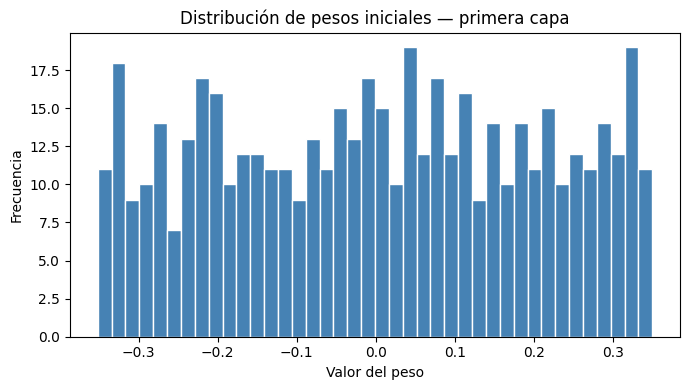

In [8]:
# Observar cómo PyTorch inicializa los pesos
primera_capa = list(model.parameters())[0]  # W de la primera capa: shape (64, 8)
print(f"Shape de W₁: {primera_capa.shape}")
print(f"Media de W₁: {primera_capa.data.mean():.4f}")
print(f"Std  de W₁: {primera_capa.data.std():.4f}")
print(f"Min  de W₁: {primera_capa.data.min():.4f}")
print(f"Max  de W₁: {primera_capa.data.max():.4f}")

plt.figure(figsize=(7, 4))
plt.hist(primera_capa.data.cpu().numpy().flatten(), bins=40,
         color="steelblue", edgecolor="white")
plt.title("Distribución de pesos iniciales — primera capa")
plt.xlabel("Valor del peso")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

**Pregunta 2.6 ¿Qué distribución tienen los pesos iniciales? PyTorch usa por default la inicialización de Kaiming He para capas con ReLU. ¿Por qué no inicializar todos los pesos en cero? ¿Qué problema fundamental causaría eso durante el entrenamiento? (Pista: piensa en lo que haría backpropagation si todos los pesos fueran idénticos.)**

Tienen una distribución relativamente normal, con algo de sesgo negativo. Si todos los pesos fueran 0, o idénticos de cualquier modo, las neuronas serían prácticamente idénticas. Al tomar el error, repartiría equitativamente entre ellas. Si tienes los mismos pesos, no tiene caso tener más neuronas.

# Parte 3: Entrenamiento

## Funcion de pérdida y optimizador

In [9]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

**Pregunta 3.1 Se usa MSELoss. ¿Por qué MSE y no cross-entropy? ¿En qué tipo de tarea usarías cross-entropy binary y en cuál usarías cross-entropy multiclase?**

Se utiliza cross-entropy para clasificación por sus características discretas. Al ser una tarea de regresión, el MSE es mucho más apto para este modelo, por su tranajar de manera continua.

**Pregunta 3.2 El optimizador es Adam con lr=1e-3. En clase viste que Adam mantiene estimaciones del primer y segundo momento del gradiente. Explica con tus palabras qué significa que los parámetros que "varían mucho" reciban pasos más pequeños. ¿Por qué eso puede ser ventajoso frente a un learning rate fijo para todos?**

El que los parámetros que varían mucho tengan pesos pequeños, significa que dichas variaciones grandes no tendrán un efecto grande en el modelo. Siguen inlfuenciando, pero un valor abruptamente diferente del resto no causará una disrupción en el modelo.

## Training loop (con early stopping)


In [10]:
def train_model(model, train_loader, X_val_t, y_val_t,
                n_epochs=300, patience=20, verbose_every=25):
    """
    Entrena el modelo con early stopping basado en val loss.
    
    Args:
        patience : cuántos epochs tolerar sin mejora en val loss
                   antes de detener el entrenamiento.
    Returns:
        Historial de train loss y val loss por epoch.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    train_history = []
    val_history   = []
    
    # Variables para early stopping
    best_val_loss   = float("inf")
    best_weights    = None
    epochs_no_improv = 0
    stopped_at      = n_epochs
    
    for epoch in range(n_epochs):
        
        # ── MODO ENTRENAMIENTO ──────────────────────────────────────
        model.train()
        batch_losses = []
        
        for X_batch, y_batch in train_loader:
            
            # Paso 1: limpiar gradientes acumulados
            optimizer.zero_grad()
            
            # Paso 2: forward pass
            y_pred = model(X_batch)
            
            # Paso 3: calcular pérdida
            loss = criterion(y_pred, y_batch)
            
            # Paso 4: backward pass (calcular gradientes)
            loss.backward()
            
            # Paso 5: actualizar pesos
            optimizer.step()
            
            batch_losses.append(loss.item())
        
        train_loss = np.mean(batch_losses)
        train_history.append(train_loss)
        
        # ── MODO EVALUACIÓN ─────────────────────────────────────────
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        val_history.append(val_loss)
        
        # ── EARLY STOPPING ──────────────────────────────────────────
        if val_loss < best_val_loss - 1e-4:
            best_val_loss    = val_loss
            best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improv = 0
        else:
            epochs_no_improv += 1
        
        if epochs_no_improv >= patience:
            stopped_at = epoch + 1
            print(f"  Early stopping en epoch {stopped_at}.")
            break
        
        if (epoch + 1) % verbose_every == 0:
            print(f"  Epoch {epoch+1:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")
    
    # Restaurar los mejores pesos encontrados
    if best_weights is not None:
        model.load_state_dict(best_weights)
    
    return train_history, val_history, stopped_at


# Entrenamiento
print("Entrenando modelo base...")
train_hist, val_hist, stopped = train_model(model, train_loader, X_val_t, y_val_t)
print(f"Entrenamiento completado. Detenido en epoch {stopped}.")


Entrenando modelo base...
  Epoch  25 | Train: 0.0916 | Val: 0.1374
  Epoch  50 | Train: 0.0543 | Val: 0.1169
  Epoch  75 | Train: 0.0419 | Val: 0.1100
  Epoch 100 | Train: 0.0344 | Val: 0.1070
  Early stopping en epoch 114.
Entrenamiento completado. Detenido en epoch 114.


**Pregunta 3.3 — La más importante de esta sección. Explica con tus propias palabras qué hace cada uno de los 5 pasos dentro del loop de batches. No copies las definiciones de los slides: formula la explicación en términos de lo que está ocurriendo matemáticamente con los pesos de esta red específica, con este dataset concreto.**

1. El primero paso simplemente reinicializa los gradientes (los ahce 0). Esto es importante para que los del batch anterior no irrumpan al actual.
2. El segundo es el paso de datos por la red para calcular una predicción (claro, empezando muy poco acertada y mejorando a la larga con los batches).
3. Calcula la pérdida del modelo, es decir, cuánto erró el modelo al predecir del valor verdadero.
4. Aquí se efectúa el backpropagation. Calcula los gradientes de los diferentes pesos para asignar cierta "responsabilidad" de la pérdida (error) a cada peso mediante el uso de derivadas.
5. Finalmente, se utilizan esas gradientes para actualizar los pesos del modelo, ya sea para subirlos o bajarlos dependiendo del peso y su influencia en el error según el backpropagation. Esto prepara para el siguiente batch.

**Pregunta 3.4 optimizer.zero_grad() está dentro del loop de batches, no fuera. ¿Qué pasaría si lo movieras fuera del loop (es decir, que se ejecutara solo una vez al inicio de cada epoch)? ¿Los pesos se actualizarían correctamente?**

Si solo se ejecutara una vez, cada batch sumaría a los gradientes anteriores. El modelo totalmente malinterpretaría esto como que los errores siguen creciendo e intentaría arreglar errores que ya no existen inicialmente. En cierto punto, se saldría totalmente de control y tronaría el modelo. Sería inservible.
    
**Pregunta 3.5 El bloque de evaluación usa model.eval() y torch.no_grad(). Son dos cosas distintas:**
- **model.eval() cambia el comportamiento de ciertas capas. ¿Cuáles capas de tu modelo se comportan diferente en modo evaluación vs entrenamiento, y por qué?**

Es posible que ciertas capas ocultas (las de tipo Dropout) se comporten aleatoriamente como parte del entrenamiento. El model.eval() se usa como estándar para detener esos comportamientos y de otros tipos, para que sean deterministas y den siempre el mismo resultado una vez ya se entrenó el modelo. 

- **torch.no_grad() evita que PyTorch construya el grafo computacional. ¿Qué es ese grafo y para qué lo usa backpropagation? ¿Por qué no lo necesitas durante la evaluación?**

Como dice su nombre, ese grafo se utiliza para el backpropagation mayormente. Este registra, no solo los resultados, sino cómo se llega a cada uno de ellos para poder devolver esa información a sus orígenes (los pesos iniciales) y poder cambiar el modelo. Como este grafo se utiliza paara el backpropagation, no es útil una vez se entrenó el modelo. Al utilizar el modelo, ya no necesitas se gaste memoria en los procesos, solo necesitas los resultados.

**Pregunta 3.6 El early stopping implementado guarda best_weights y los restaura al final con model.load_state_dict(best_weights). ¿Por qué es necesario ese paso de restauración? ¿Qué le estarías devolviendo al usuario si no lo hicieras?**

Se van guardando los best weights en ese diccionario. Si no se restauran al modelo final, el modelo se quedará con la última iteración de cambio en el modelo. No garantiza la mejor capacidad del modelo. Le entregas al usuario el último intento, sin importar cuán bueno sea. Se guardaría el mejor modelo en ese diccionario pero no se usaría.


## Curvas de aprendizaje

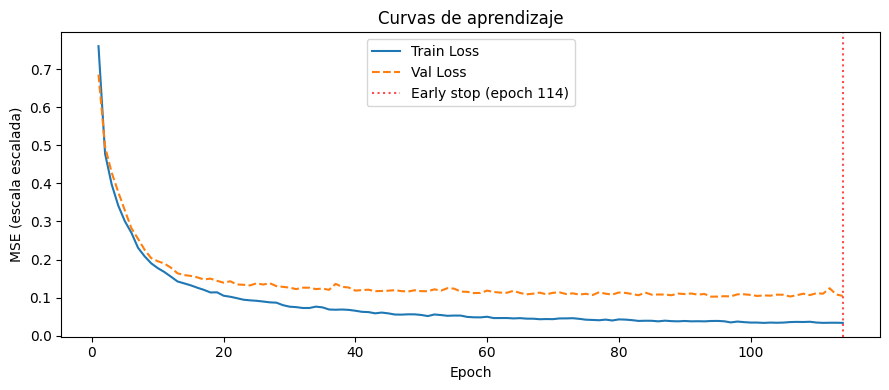

In [11]:
def plot_learning_curves(train_hist, val_hist, stopped_at, title="Curvas de aprendizaje"):
    plt.figure(figsize=(9, 4))
    epochs = range(1, len(train_hist) + 1)
    plt.plot(epochs, train_hist, label="Train Loss", linewidth=1.5)
    plt.plot(epochs, val_hist,   label="Val Loss",   linewidth=1.5, linestyle="--")
    plt.axvline(x=stopped_at, color="red", linestyle=":", alpha=0.7,
                label=f"Early stop (epoch {stopped_at})")
    plt.xlabel("Epoch")
    plt.ylabel("MSE (escala escalada)")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_learning_curves(train_hist, val_hist, stopped)

**Pregunta 3.7 a) ¿El val loss converge suavemente o tiene ruido? ¿A qué atribuyes eso? b) ¿Hay señal de overfitting? ¿Cómo lo identificas visualmente — no con un número, sino con la forma de las curvas? c) ¿La línea de early stopping está "en el lugar correcto", o debería haber esperado más o parado antes?**

a) El Val Loss posee pequeñas señales de ruido, pero esperadas. Tiene sentido al solamente 1000 datos con los que trabajamos, y ya muchos menos en validación; cada dato tiene más importancia que una base de datos masiva.}

b) Existe una pequeña señal de overfitting. Esto se ve al momento del epoch 30, donde la curva de entrenamiento sigue bajando su MSE mientras que la de validación ya se mantiene sstable.

c) La línea de early stopping está aceptable, pero podría estar mucho antes. Alrededor del eooch 70-80, la Val Loss bajó lo que iba a bajar. No está sobreextendido a niveles peligrosos, pero tampoco es lo ideal.


# Parte 4: Evaluación en escala original

## Métricas

In [12]:
def evaluate(model, X_t, y_true_sc, scaler_y, label=""):
    model.eval()
    with torch.no_grad():
        y_pred_sc = model(X_t).cpu().numpy()
    y_pred_mpa = scaler_y.inverse_transform(y_pred_sc)
    y_true_mpa = scaler_y.inverse_transform(y_true_sc)
    rmse = np.sqrt(mean_squared_error(y_true_mpa, y_pred_mpa))
    mae  = np.mean(np.abs(y_true_mpa - y_pred_mpa))
    if label:
        print(f"{label:30s} | RMSE: {rmse:.2f} MPa | MAE: {mae:.2f} MPa")
    return rmse, mae, y_pred_mpa, y_true_mpa

rmse_nn, mae_nn, y_pred_mpa, y_true_mpa = evaluate(
    model, X_test_t, y_test_sc, scaler_y, "Red Neuronal (base)"
)

Red Neuronal (base)            | RMSE: 5.22 MPa | MAE: 3.61 MPa


**Pregunta 4.1 Reportas tanto RMSE como MAE. ¿En qué se diferencian conceptualmente? Si el RMSE es notablemente mayor que el MAE, ¿qué sugiere eso sobre los errores del modelo?**

El RMSE es menos permisivo de errores grandes (castiga más errores individuales grandes), mientras el MAE lo hace en promedio (le da igual un error de 100 que cien errores de 1; castiga todos los errores por igual). Como el RMSE es algo mayor, la distribución de errores no es uniforme. En promedio, es 3.61 el error, pero hay algunos errores que pueden llegar a ser más altos.

## Gráficas diagnósticas

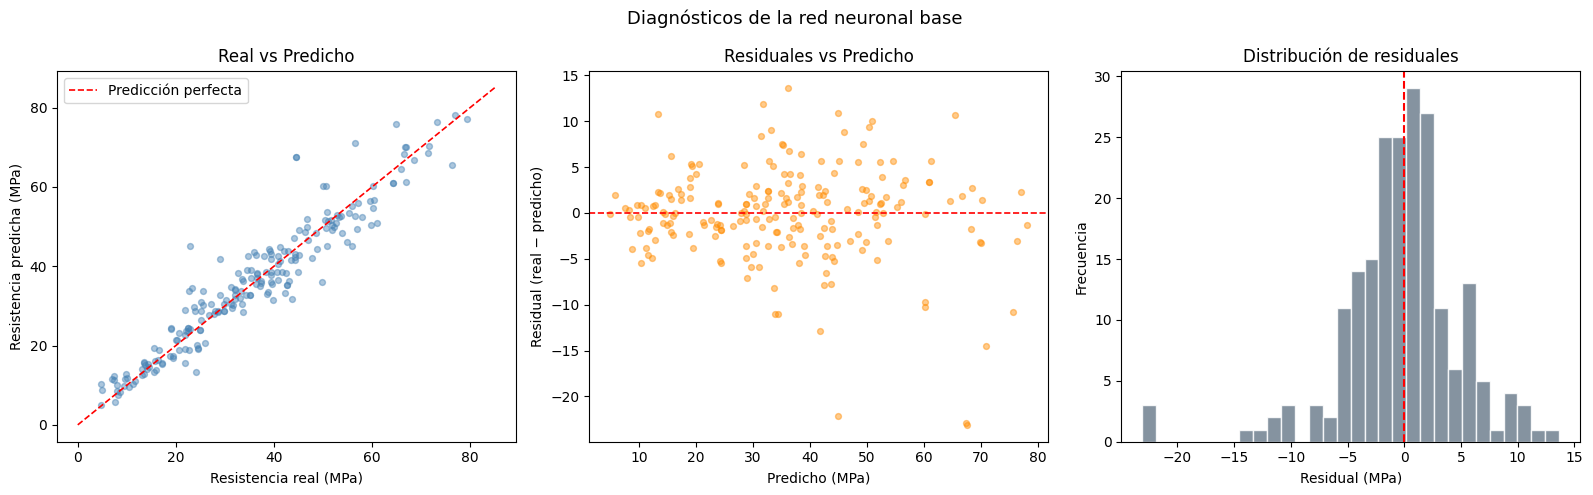

Media de residuales  : -0.199
Std  de residuales   : 5.213


In [13]:
residuals = y_true_mpa.flatten() - y_pred_mpa.flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Gráfica 1: Real vs Predicho
ax = axes[0]
ax.scatter(y_true_mpa, y_pred_mpa, alpha=0.45, s=18, color="steelblue")
lims = [0, 85]
ax.plot(lims, lims, "r--", linewidth=1.2, label="Predicción perfecta")
ax.set_xlabel("Resistencia real (MPa)")
ax.set_ylabel("Resistencia predicha (MPa)")
ax.set_title("Real vs Predicho")
ax.legend()

# Gráfica 2: Residuales vs Predicho
ax = axes[1]
ax.scatter(y_pred_mpa, residuals, alpha=0.45, s=18, color="darkorange")
ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
ax.set_xlabel("Predicho (MPa)")
ax.set_ylabel("Residual (real − predicho)")
ax.set_title("Residuales vs Predicho")

# Gráfica 3: Distribución de residuales
ax = axes[2]
ax.hist(residuals, bins=30, color="slategray", edgecolor="white", alpha=0.85)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Residual (MPa)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de residuales")

plt.suptitle("Diagnósticos de la red neuronal base", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Media de residuales  : {residuals.mean():.3f}")
print(f"Std  de residuales   : {residuals.std():.3f}")

**Pregunta 4.2 Para cada una, escribe al menos dos observaciones:**
- **Real vs Predicho: ¿hay sesgo sistemático? ¿el modelo predice igual de bien en valores bajos que en valores altos de resistencia?**

Parece haber un poco más de variación en los valores altos, pero nada significativo. Probablemente baje un poco la precisión con valores altos.
El modelo en sí parece estimar muy bien las resistencias, alineándose con el camino de los data points.

- **Residuales vs Predicho: ¿hay homocedasticidad o el patrón de los errores cambia con el valor predicho?**

Aunque hay algunos residuos atípicos, aparentan formar esa nube aleatoria de puntos. Esto indica homocedasticidad (de manera práctica, porque nada varía completamente igual).
Los puntos muy alejados (menores que -20) fueron una sobreestimación del valor real. Son pocos, pero estos porbablemente son los que inflaron el RMSE. 

- **Distribución de residuales: ¿es aproximadamente simétrica? ¿hay outliers evidentes?**

La distribución sí es aproximadamente simétrica. Claro, están los outliers menores que 20, pero son un pequeño subconjunto de datos y no definen la actitud general del modelo. Esta gráfica indica una homocedasticidad.
Como los errores parecen estar concentrados junto al 0, parece que la gran parte de las estimaciones no difieren por mucho del valor real.

**Pregunta 4.3 El supuesto de normalidad de residuales importaba mucho en regresión lineal para inferencia estadística (intervalos de confianza, p-values). En una red neuronal entrenada por minimización de MSE, ¿ese supuesto sigue siendo necesario? ¿Qué sí y qué no cambia?**

No es estrictamente necesaria la normalidad, porque lo que busca la red es la minimización general del error. Esto es solamente una herramienta de predicción. Con que los resiudales se distribuyan alrededor de 0, podemos decir que es insesgado.
Si se quiere utilizar para explicar la realidad, sí puede afectar más. Lo que es cierto es que la falta de normalidad afecta la inferencia que podemos hacer estadísticamente hablando, porque al perderse los supestos, las conclusiones de los datos se comprometen.

# Parte 5: Experimentos sistemáticos

## Experimento 1: Learning rate


In [14]:
def experimento_lr(lr_list, n_epochs=300):
    resultados = {}
    for lr in lr_list:
        m = ConcreteNet(8, 64, 1, dropout_rate=0.0).to(device)
        opt = optim.Adam(m.parameters(), lr=lr)
        crit = nn.MSELoss()
        hist_train, hist_val = [], []
        for _ in range(n_epochs):
            m.train()
            bl = []
            for Xb, yb in train_loader:
                opt.zero_grad()
                loss = crit(m(Xb), yb)
                loss.backward()
                opt.step()
                bl.append(loss.item())
            m.eval()
            with torch.no_grad():
                vl = crit(m(X_val_t), y_val_t).item()
            hist_train.append(np.mean(bl))
            hist_val.append(vl)
        resultados[lr] = (hist_train, hist_val)
        print(f"  lr={lr:.0e} | Val Loss final: {hist_val[-1]:.4f}")
    return resultados

print("Experimento: learning rate")
res_lr = experimento_lr([1e-1, 1e-2, 1e-3, 1e-4])

Experimento: learning rate
  lr=1e-01 | Val Loss final: 0.2613
  lr=1e-02 | Val Loss final: 0.0932
  lr=1e-03 | Val Loss final: 0.1103
  lr=1e-04 | Val Loss final: 0.1263


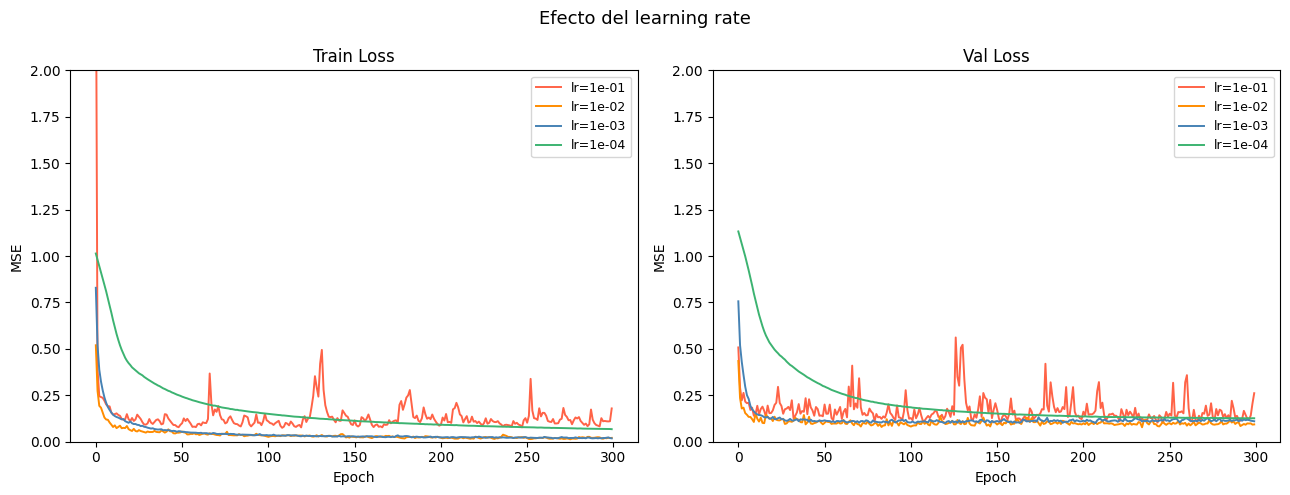

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ["tomato", "darkorange", "steelblue", "mediumseagreen"]
lrs    = [1e-1, 1e-2, 1e-3, 1e-4]

for ax_idx, key in enumerate(["Train", "Val"]):
    ax = axes[ax_idx]
    for lr, color in zip(lrs, colors):
        hist = res_lr[lr][ax_idx]
        ax.plot(hist, label=f"lr={lr:.0e}", color=color, linewidth=1.4)
    ax.set_title(f"{key} Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE")
    ax.legend(fontsize=9)
    ax.set_ylim(0, 2.0)

plt.suptitle("Efecto del learning rate", fontsize=13)
plt.tight_layout()
plt.show()

**Pregunta 5.1 Describe el comportamiento para cada learning rate. ¿Cuál diverge, cuál converge demasiado lento, cuál tiene el mejor balance? Conecta lo que ves con lo que viste en los slides 100–102 del lunes.**

- El 1e-01 diverge. Esto se ve por su alta inestabilidad e incapacidad de regularse alrededor de un valor.
- El 1e-02 es un poco apresurado en su convergencia y tiene algo de ruido, pero suficientemente moderado
- El 1e-03 es probablemente el más balanceado, pues no converege muy rápido ni muy lento y es estable.
- El 1e-04 tarda demasiado en converger en un valor.

Esto se da porque un learning rate demasiado alto causa que cada epoch influencie demasiado el modelo y nunca converja. Un learning rate muy pequeño causa una necesidad de uso computacional innecesaria. La clave está en encontrar ese punto medio que puede variar según el modelo y los datos.

## Experimento 2: Tamaño del Batch

In [16]:
def experimento_batch(batch_sizes, n_epochs=200):
    resultados = {}
    for bs in batch_sizes:
        loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        m = ConcreteNet(8, 64, 1).to(device)
        opt = optim.Adam(m.parameters(), lr=1e-3)
        crit = nn.MSELoss()
        hist_train, hist_val = [], []
        for _ in range(n_epochs):
            m.train()
            bl = []
            for Xb, yb in loader:
                opt.zero_grad()
                loss = crit(m(Xb), yb)
                loss.backward()
                opt.step()
                bl.append(loss.item())
            m.eval()
            with torch.no_grad():
                vl = crit(m(X_val_t), y_val_t).item()
            hist_train.append(np.mean(bl))
            hist_val.append(vl)
        rmse, _, _, _ = evaluate(m, X_test_t, y_test_sc, scaler_y)
        resultados[bs] = {"train": hist_train, "val": hist_val, "rmse_test": rmse}
        print(f"  batch={bs:4d} | Val Loss final: {hist_val[-1]:.4f} | RMSE test: {rmse:.2f} MPa")
    return resultados

print("Experimento: batch size")
res_batch = experimento_batch([8, 32, 128, 824])  # 824 ≈ todo el train set

Experimento: batch size
  batch=   8 | Val Loss final: 0.0946 | RMSE test: 5.21 MPa
  batch=  32 | Val Loss final: 0.0760 | RMSE test: 4.91 MPa
  batch= 128 | Val Loss final: 0.1255 | RMSE test: 5.53 MPa
  batch= 824 | Val Loss final: 0.1050 | RMSE test: 6.35 MPa


**Pregunta 5.2 Anota los RMSE de prueba para cada batch size. ¿Hay diferencias notables? En clase viste el trade-off entre batch pequeño (gradiente ruidoso) y batch grande (gradiente estable). ¿Ese trade-off se manifiesta en tus resultados? ¿Por qué batch=824 es equivalente a batch gradient descent en este caso?**

Se ve en los resultados que un batch muy pequeño hace que este sea ruidoso pues hay mayor variedad en pocos datos. Por otro lado, uno muy grande hace menos cambios en los pesos, por lo que adapta muy poco; ya en el último de algún modo es como simplemente realizar regresión lineal (le trivializa a la red neuronal esa característica readaptativa). El batch de 824 es igual al batch gradient descent porque utiliza todos los datos de entrenamiento.

## Experimento 3: Arquitectura

In [17]:
arquitecturas = {
    "Shallow-64"    : {"hidden_dim": 64,  "n_layers": 1},
    "Base (2x64)"   : {"hidden_dim": 64,  "n_layers": 2},
    "Deep (3x64)"   : {"hidden_dim": 64,  "n_layers": 3},
    "Wide (2x256)"  : {"hidden_dim": 256, "n_layers": 2},
    "Tiny (2x16)"   : {"hidden_dim": 16,  "n_layers": 2},
}

# Para variar el número de capas necesitas modificar ConcreteNet.
# Aquí tienes una versión flexible:

class FlexNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim, dropout_rate=0.0):
        super(FlexNet, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
                       nn.Dropout(p=dropout_rate)]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.net(x)

resultados_arch = {}
for nombre, cfg in arquitecturas.items():
    torch.manual_seed(SEED)
    m = FlexNet(8, cfg["hidden_dim"], cfg["n_layers"], 1).to(device)
    th, vh, st = train_model(m, train_loader, X_val_t, y_val_t,
                              n_epochs=300, patience=25, verbose_every=999)
    rmse, mae, _, _ = evaluate(m, X_test_t, y_test_sc, scaler_y, nombre)
    n_params = sum(p.numel() for p in m.parameters())
    resultados_arch[nombre] = {"rmse": rmse, "params": n_params}

  Early stopping en epoch 128.
Shallow-64                     | RMSE: 5.95 MPa | MAE: 4.46 MPa
  Early stopping en epoch 119.
Base (2x64)                    | RMSE: 5.22 MPa | MAE: 3.61 MPa
  Early stopping en epoch 115.
Deep (3x64)                    | RMSE: 5.39 MPa | MAE: 3.60 MPa
  Early stopping en epoch 156.
Wide (2x256)                   | RMSE: 4.79 MPa | MAE: 3.22 MPa
  Early stopping en epoch 144.
Tiny (2x16)                    | RMSE: 6.45 MPa | MAE: 4.74 MPa



Arquitectura	Parámetros (con sesgos)	         RMSE Test MPa)
Shallow-64		641                              5.95
Base (2×64)		4801                             5.22                      
Deep (3×64)		8961                             5.39                      
Wide (2×256)    68353                            4.79                      
Tiny (2×16)	    433                              6.45                      

**Pregunta 5.3 Llena la tabla y responde: a) ¿El modelo con más parámetros tiene el mejor RMSE? ¿Qué dice eso sobre la relación entre tamaño del modelo y desempeño en datasets pequeños? b) ¿Cuál arquitectura tiene la mejor relación parámetros/desempeño? c) Elige la arquitectura que usarías en producción para este problema específico y justifica la elección considerando no solo el RMSE sino también el número de parámetros.**

a) Sí, el wide tuvo el mayor RMSE. Puede significar que es mejor tener más parámetros que mayor número de capas con menos datos, pues si observamos el cambio de Base a Deep, subió el error al agregar una capa, pero lo baj+o al agregar parámetros (Wide).

b) El Base es el más sólido en cuanto a parámetros y desempeño. Es ligero y tiene buena generalización (segundo menor RMSE). Wide utiliza alrededor de 4 veces la cantidad de parámetros con un desempeño ligeramente mejor.

c) Yo utilizaría el Base. Esta es eficiente (mejor en este aspecto que Wide, evita overfitting (consecuencia de Deep), y sobre todo funcional (a diferencia de Tiny). Aún 4801 parámetros son cantidad buena sin sobrepasarse, por lo que se permite este aumento por mayor precisión comparado al Shallow-64.

## Experimento 4: Dropout como regularización

In [18]:
tasas_dropout = [0.0, 0.1, 0.3, 0.5]
resultados_dropout = {}

for rate in tasas_dropout:
    torch.manual_seed(SEED)
    m = ConcreteNet(8, 64, 1, dropout_rate=rate).to(device)
    th, vh, st = train_model(m, train_loader, X_val_t, y_val_t,
                              n_epochs=300, patience=25, verbose_every=999)
    rmse, _, _, _ = evaluate(m, X_test_t, y_test_sc, scaler_y,
                              f"Dropout={rate}")
    resultados_dropout[rate] = {"rmse": rmse, "train": th, "val": vh}

  Early stopping en epoch 119.
Dropout=0.0                    | RMSE: 5.22 MPa | MAE: 3.61 MPa
  Early stopping en epoch 181.
Dropout=0.1                    | RMSE: 5.20 MPa | MAE: 3.61 MPa
  Early stopping en epoch 125.
Dropout=0.3                    | RMSE: 6.10 MPa | MAE: 4.61 MPa
  Early stopping en epoch 104.
Dropout=0.5                    | RMSE: 6.62 MPa | MAE: 5.27 MPa


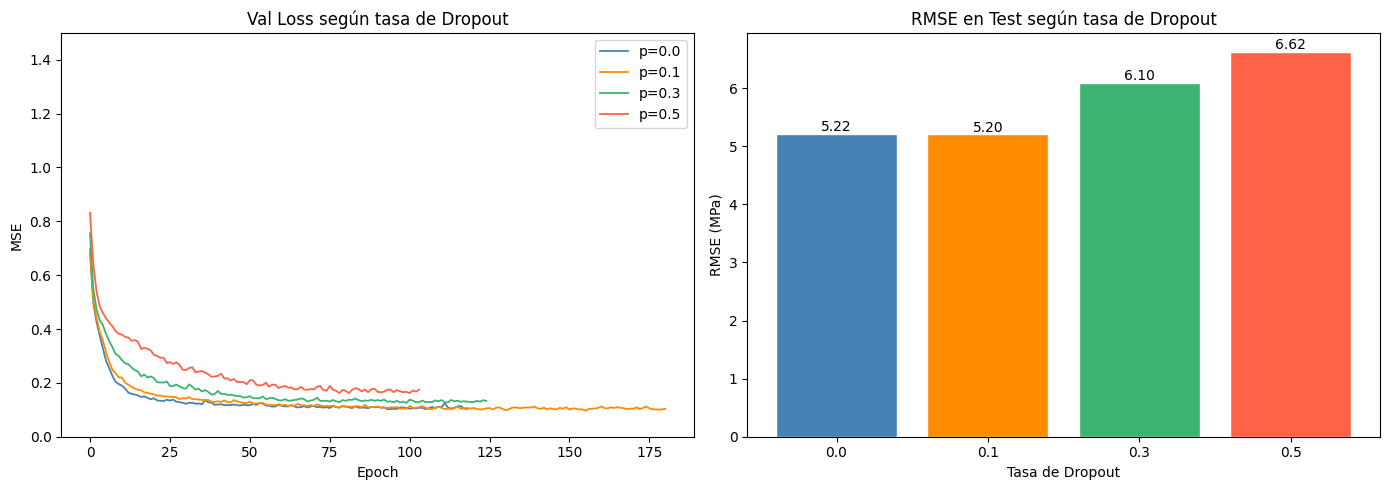

In [19]:


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores = ["steelblue", "darkorange", "mediumseagreen", "tomato"]

# Curvas val loss
ax = axes[0]
for rate, color in zip(tasas_dropout, colores):
    vh = resultados_dropout[rate]["val"]
    ax.plot(vh, label=f"p={rate}", color=color, linewidth=1.3)
ax.set_title("Val Loss según tasa de Dropout")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE")
ax.legend(); ax.set_ylim(0, 1.5)

# RMSE final
ax = axes[1]
rmses = [resultados_dropout[r]["rmse"] for r in tasas_dropout]
bars  = ax.bar([str(r) for r in tasas_dropout], rmses,
               color=colores, edgecolor="white")
ax.set_title("RMSE en Test según tasa de Dropout")
ax.set_xlabel("Tasa de Dropout"); ax.set_ylabel("RMSE (MPa)")
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f"{val:.2f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

**Pregunta 5.4 ¿A qué tasa de Dropout se obtiene el mejor RMSE? ¿Tiene sentido intuitivo que Dropout muy alto (0.5) pueda aumentar el error? Explica en términos del concepto de underfitting.**

La p=0.1 obtiene el mejor MSE. Este es relativamente estable y converge a buena velocidad (ni precipitado ni lento). Un dropout muy alto del 0.5, es prácticamente apagar medio modelo cada epoch lo cual lo deja muy perdido. Apagar unas pocas permite que el modelo genere distintas conexiones entre variables y no se quede con lo general (mientras no se pierde completamente tampoco).

**Pregunta 5.5 Dropout se desactiva durante la inferencia (model.eval()). Si olvidaras llamar model.eval() antes de evaluar en test, ¿qué efecto concreto tendría en tus predicciones? ¿Serían deterministas o no?**

En este caso, las predicciones del modelo no serían deterministas. Quita un poco el propósito del modelo estar aleatoriamente eliminando ciertas partes de él al usarlo, pues generaría resultados aleatorios (bajo cierto margen, pero igualmente aleatorios).

# Parte 6: Inspección de gradientes

## Gradientes por capa

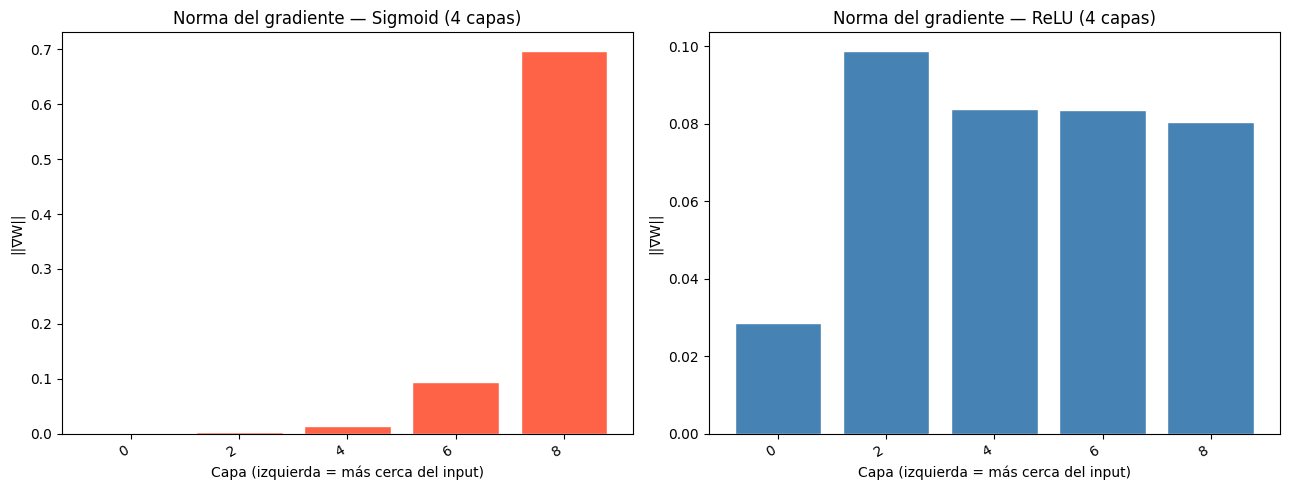

In [20]:
# Entrenamos brevemente un modelo con sigmoid para comparar contra ReLU

class NetSigmoid(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=64, output_dim=1, n_layers=4):
        super(NetSigmoid, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Sigmoid()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid()]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class NetReLU(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=64, output_dim=1, n_layers=4):
        super(NetReLU, self).__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers += [nn.Linear(hidden_dim, output_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def get_grad_norms(model_class, X_t, y_t, n_steps=50):
    """
    Realiza n_steps de entrenamiento y registra la norma del gradiente
    de cada capa lineal al final.
    """
    torch.manual_seed(SEED)
    m = model_class().to(device)
    opt = optim.SGD(m.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    
    for _ in range(n_steps):
        m.train()
        opt.zero_grad()
        loss = crit(m(X_t), y_t)
        loss.backward()
        opt.step()
    
    # Recolectar normas del gradiente por capa lineal
    grad_norms = []
    layer_names = []
    for name, param in m.named_parameters():
        if "weight" in name and param.grad is not None:
            grad_norms.append(param.grad.norm().item())
            layer_names.append(name.replace(".weight", ""))
    
    return layer_names, grad_norms

names_sig, norms_sig = get_grad_norms(NetSigmoid, X_train_t, y_train_t)
names_rel, norms_rel = get_grad_norms(NetReLU,    X_train_t, y_train_t)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, names, norms, title, color in [
    (axes[0], names_sig, norms_sig, "Sigmoid (4 capas)", "tomato"),
    (axes[1], names_rel, norms_rel, "ReLU (4 capas)",    "steelblue"),
]:
    ax.bar(range(len(norms)), norms, color=color, edgecolor="white")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels([n.split(".")[-1] for n in names], rotation=30, ha="right")
    ax.set_title(f"Norma del gradiente — {title}")
    ax.set_ylabel("||∇W||")
    ax.set_xlabel("Capa (izquierda = más cerca del input)")

plt.tight_layout()
plt.show()

**Pregunta 6.1  ¿Ves diferencia entre la red con Sigmoid y la red con ReLU en cuanto a cómo se distribuyen los gradientes entre capas? ¿La primera capa (más a la izquierda) recibe gradientes de magnitud comparable a la última? Conecta lo que ves con la explicación de vanishing gradients de los slides 40–41 del lunes.**

Al utilizar el sigmoide, los gradientes no lelgan a afectar (al menos no significativamente) a los pesos iniciales. Desproporcionalmente cambia a las capas más avanzadas porque mientras más se atrasa, las derivadas se van enchiqueciendo. Esto fue un problema histórico (vanishing gradient) que más adelante fue solucionado mediante el uso de ReLU en ciertas áreas, la cual tiene una derivada de 1 en todos sus valores positivos. Esto permite el flujo seguido del gradiente en todas las capas.

**Pregunta 6.2 En el código usamos optim.SGD en lugar de Adam deliberadamente para este experimento. ¿Por qué Adam podría enmascarar el efecto del vanishing gradient y hacer menos visible la diferencia?**

Adam es adaptativo (por eso se utiliza tanto), y tiene estrategias como la de "momentum" que se vio en clase que permite que las capas iniciales sí aprendan algo, pero se pierde la interpretación de vanishing gradient que sí sigue vigente. SGD no tiene esas correcciones y permite ver la realidad de la pérdida.

# Parte 7: Depuración

In [21]:
scaler_debug = StandardScaler()
X_train_bug = scaler_debug.fit_transform(X_train)
X_test_bug  = scaler_debug.transform(X_test)

torch.manual_seed(SEED)
model_debug = ConcreteNet(8, 64, 1).to(device)
opt_debug   = optim.Adam(model_debug.parameters(), lr=1e-3)
crit_debug  = nn.MSELoss()

X_tr = to_tensor(X_train_bug)
y_tr = to_tensor(y_train_sc)

for epoch in range(50):
    model_debug.train()
    for Xb, yb in DataLoader(TensorDataset(X_tr, y_tr), batch_size=32):
        loss = crit_debug(model_debug(Xb), yb)
        opt_debug.zero_grad()
        loss.backward()                              
        opt_debug.step()

model_debug.eval()
y_debug_pred = model_debug(to_tensor(X_test_bug)).detach().numpy()

print(f"Predicción ejemplo: {y_debug_pred[0]}")

Predicción ejemplo: [-1.6552879]


**Pregunta 7.1 Identifica los tres errores. Para cada uno: a) Señala la línea exacta y el comentario que lo marca. b) Explica por qué es un error (qué produce que es incorrecto o problemático). c) Escribe la corrección.**

**Error # 1**

X_test_bug  = scaler_debug.fit_transform(X_test) --> X_test_bug  = scaler_debug.transform(X_test)

Esto es claramente un error porque los datos de prueba deben ser escalados con base en los de entrenamiento para que sea equivalente a la escala del modelo, sin proporcionar información extra (Data Leakage)

**Error # 2**

        loss.backward()                              opt_debug.zero_grad() 
        opt_debug.step()             ----->          loss.backward()
        opt_debug.zero_grad()                        opt_debug.step()

Este cambio ya era uno visto anteriormente. Se debe primero reiniciar los gradientes antes de sumarles los siguientes para que no afecten los gradientes ya utilizados.

**Error # 3**

y_debug_pred = model_debug(X_test_t).detach().numpy() -->    
y_debug_pred = model_debug(to_tensor(X_test_bug)).detach().numpy()

Se deben de utilizar los datos que se acaban de escalar para esto, no otros. Además, se debe cambiar el formato para que se utilicen apropiadamente.

# Parte 8: Comparación final y análisis crítico

## Ridge como línea base


In [22]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

# Ridge con búsqueda de alpha en el mismo train set
ridge_cv = GridSearchCV(
    Ridge(), {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    cv=5, scoring="neg_mean_squared_error"
)
ridge_cv.fit(X_train_sc, y_train_sc.ravel())
print(f"Mejor alpha Ridge: {ridge_cv.best_params_['alpha']}")

y_ridge_sc  = ridge_cv.predict(X_test_sc).reshape(-1, 1)
y_ridge_mpa = scaler_y.inverse_transform(y_ridge_sc)
rmse_ridge  = np.sqrt(mean_squared_error(y_true_mpa, y_ridge_mpa))
mae_ridge   = np.mean(np.abs(y_true_mpa - y_ridge_mpa))

print(f"\nComparación final:")
print(f"{'Modelo':<35} {'RMSE (MPa)':>12} {'MAE (MPa)':>12} {'Parámetros':>12}")
print("-" * 75)
print(f"{'Ridge (mejor alpha)':<35} {rmse_ridge:>12.2f} {mae_ridge:>12.2f} {'9':>12}")
print(f"{'Red Neuronal (base 2x64)':<35} {rmse_nn:>12.2f} {mae_nn:>12.2f}")
# Añade aquí la mejor arquitectura que encontraste en la sección 5.3

Mejor alpha Ridge: 0.01

Comparación final:
Modelo                                RMSE (MPa)    MAE (MPa)   Parámetros
---------------------------------------------------------------------------
Ridge (mejor alpha)                        11.04         8.84            9
Red Neuronal (base 2x64)                    5.22         3.61


**Pregunta 8.1 ¿Cuál modelo tiene menor RMSE? ¿La diferencia es estadísticamente y prácticamente significativa?**

La red tiene menor RMSE, y en definitiva es signficativa. Tiene menos de la mitad del RMSE, reduciendo significativamente el error del modelo. Además, en el contexto, un RMSE del 11 es demasiado si queremos que el mnodelo sea útil para predecir la resistencia en la realidad.

## Gráfica comparativa de residuales

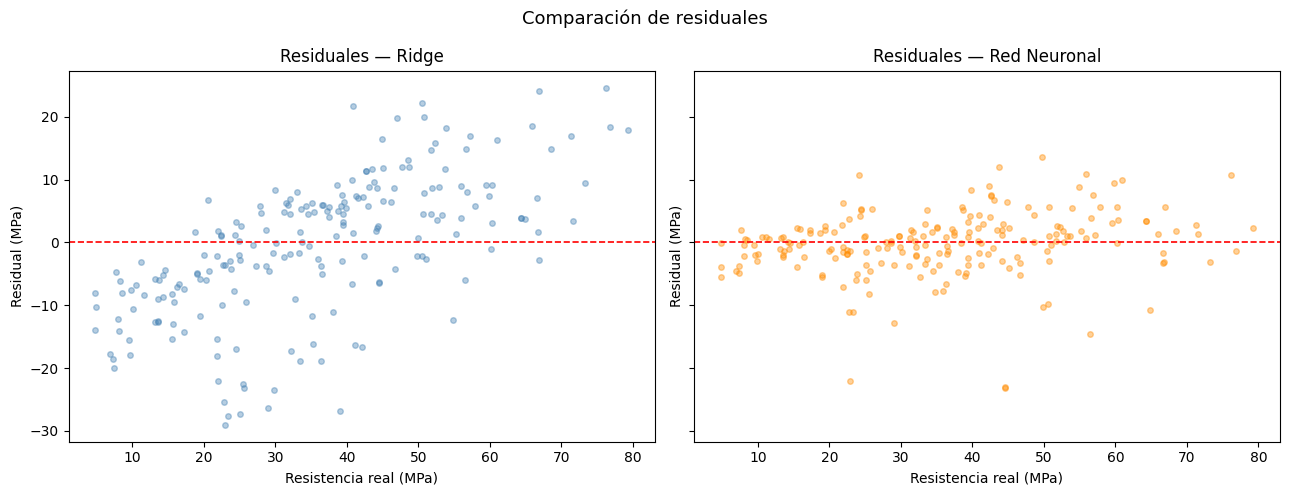

In [23]:
resid_ridge = y_true_mpa.flatten() - y_ridge_mpa.flatten()
resid_nn    = y_true_mpa.flatten() - y_pred_mpa.flatten()

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, resid, title, color in [
    (axes[0], resid_ridge, "Residuales — Ridge",          "steelblue"),
    (axes[1], resid_nn,    "Residuales — Red Neuronal",   "darkorange"),
]:
    ax.scatter(y_true_mpa, resid, alpha=0.4, s=16, color=color)
    ax.axhline(0, color="red", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Resistencia real (MPa)")
    ax.set_ylabel("Residual (MPa)")
    ax.set_title(title)

plt.suptitle("Comparación de residuales", fontsize=13)
plt.tight_layout()
plt.show()

**Pregunta 8.2 ¿Hay diferencias en el patrón de residuales entre los dos modelos? ¿Alguno tiene sesgos sistemáticos que el otro no tiene?**

El segundo es el ideal, sin tener un sesgo aparente siquiera en sus residuos. Por otro aldo, el ridge muestra una tendencia lineal en sus residuos, lo cual inidcia que es un modelo que no considera factores no lineales necesarios.

## La pregunta que importa

**Pregunta 8.3 Tu red neuronal base tiene entre 4,000 y 20,000 parámetros dependiendo de la arquitectura que elegiste. Ridge tiene 9. Con esa diferencia en mente, y con los resultados en la mano, responde las siguientes preguntas con argumentos, no solo con el número de RMSE:**
**a) ¿La diferencia en RMSE es prácticamente significativa para el problema de ingeniería civil? En concreto estructural, un error de 2 MPa puede ser relevante o irrelevante según el contexto de uso. ¿Qué contextos harían esa diferencia crítica y cuáles no?**

La diferencia de RMSE de los modelos neuroanles con el Ridge en efecto es significativo. MEste es más del doble que los mejores de la neuronal, y a 11 RMSE en términos de la resistencia de cemento, este puede tener errores bastante importantes en la ingeniería civil.

Un error de 2MPa, en su mayoría, podría pensarse que muy poco para hacer una diferencia. Sin embargo, nunca se analiza esto sin el CONTEXTO de un problema. En edificois enormes con decenas o incluso cientos de pisos, la precisión de la resistencia estructural es crucial para todo tipo de cálculos y, claro, que no caiga el edificio. Otros contextos menos drásticos sí existen, como cumplimiento reglamentario legal o la efectividad de plantas que crean piezas de cemento.

**b) Si tuvieras que presentar tus resultados a un comité de ingenieros civiles que no saben nada de machine learning, ¿cuál modelo presentarías y por qué? Piensa en interpretabilidad, confianza del cliente y riesgo.**

Por la poca confiabilidad del Ridge, y la precisión necesitada en ingniería civil en cuanto a resistncia de cemento, considero que se debería utilizar la red. Aunque es menos interpretable, los errores del Ridge son demasiado altos. Sin embargo, se puede utilizar el ridge como una base para explicar ciertos patrones y respaldar la efectividad de la red. Así, el cliente entiende de cierto modo lo que sucede y confía.

**c) ¿Qué agregarías al dataset o qué cambiarías del planteamiento del problema para que una red neuronal tuviera una ventaja más clara sobre regresión lineal? Argumenta en términos de qué hace a las redes neuronales mejores que los modelos lineales.**

Se podrían agregar variables más arraigadas a la formación del cemento. Al ser un proceso químico, los simples componentes no son suficientes. Las redes sí consideran esas conexiones no lineales. En la misma nota, agregaría un mayor número de datos, pues las redes neuronales incrementan exponencialmente su efectividad con la cantidad de datos.

**d) ¿Hay consideraciones éticas en usar un modelo de caja negra para tomar decisiones de diseño estructural? Identifica al menos dos y explica quién asume el riesgo si el modelo se equivoca.**

Una consideración ética es que es más difcíl rastrear errores, mientras que en las regresiones lineales es simple encontrar de donde viene cada dato.

También es riesgoso el que se confíe el ingeniero de la efectividad del modelo cual si fuera siempre preciso, pues una confianza ciega en un modelo estadístico siempre es peligroso. 

El riesgo debe ser asumido por el ingeniero. A fin de cuentas, lo único que se le entrega a él son un reflejo a partir de datos; es su responsabilidad lo que hace con él y que aplique según su entrenamiento y experiencia también. Como científicos de datos, no aseguramos nada de un modelo, solo notamos asociaciones y proporcionamos estimaciones.

#  Parte 9: Reflexión sin código

Estas preguntas no requieren ejecutar nada. Requieren pensar.

**Pregunta 9.1 En el training loop escribiste loss.backward(). Explica qué está calculando PyTorch en esa línea en términos de la regla de la cadena. No necesitas matemática formal: usa la analogía de la cadena de responsabilidad que viste en clase y aplícala concretamente a la primera capa lineal de tu red.**

PyTorch en loss.backward() mide la pérdida entre lo predicho y el valor real. Después regresa (backpropagation) a intentar definir qué pesos son responsables de esos errores para cambiarlos. Esto se hace multiplicando derivadas locales. Así, de manera casi equitativa en cada engrane. Llega esta hasta la primera capa, donde se intenta no sea muy pequeña apra que sí tenga un efecto en su funcionalidad.

**Pregunta 9.2 El Teorema de Aproximación Universal (Cybenko, 1989) dice que una red con una sola capa oculta puede aproximar cualquier función continua. Tienes 1,030 muestras. Hay al menos tres razones distintas por las que ese teorema no garantiza RMSE cercano a cero en este dataset. Menciona tres y explica cada una.**

El teorema afirma que existe, no que nuestro algoritmo con esta cantidad de datos la pueda encontrar.

Los datos siempre pueden estar sesgados. ueden tener errores aleatorios, estar mal registrados, o resultados que sí son reales pero son influenciados por algún factor no registrado.

Finalmente, una sola capa no determina la cantidad de parámetros. Podrían ser una capa con 200,000 neuronas la "ideal". Sin embargo, en la practicidad, hacer eso involucraría una capacidad computacional irreal.

**Pregunta 9.3 En alguno de tus experimentos, ¿el val loss fue consistentemente menor que el train loss durante varias epochs? Si sí ocurrió, explica por qué es posible eso. Si no ocurrió, describe en qué condiciones podría ocurrir y qué significaría.**

No, en estos experimentos el Val Loss fue generalmente mayor (o prácticamente igual) que el Train Loss. Podría suceder si el dropout fuese muy alto, causando esa inseguridad en el entrenamiento, o si los datos de entrenamiento fueran muy ruidosos mientras los de validación eran "perfectos", por decirlo de alguna manera.

**Pregunta 9.4 Describe qué tendría que ser diferente en este problema (dataset, tarea, objetivo de negocio) para que hubieras tomado la decisión de usar una red neuronal sin hesitar. Sé específico: no digas "más datos", sino cuántos datos y qué tipo de relación entre variables justificaría la complejidad adicional.**

En el problema debería de una cantidad de datos mínimamente de 6 cifras. Tampoco hesitaría en usar una red si las variables fueran bastantes con relaciones no lineales. A escalas enormes, sería lo ideal la red, no solamente por la cantidad de datos, sino por la necesidad de generalización que cumplen las redes al tener esas cantidades de datos.

**Pregunta 9.5 A lo largo de esta actividad construiste una red neuronal desde cero. Identifica el momento en el que entendiste algo que antes era confuso — puede ser un concepto del entrenamiento, un resultado de un experimento, o la razón de existir de una línea de código. Descríbelo con precisión.**

No me quedaba claro inicialmente como se aplicaba la función ReLU en la red. Entendí el efecto de la derivada y por que la sigmoide resultaba el vanishing gradient matemáticamente, pero me perdía un poco al momento de interpretarlo en la red. Se me aclaró su aplicación en el backpropagation y por qué mantiene esa "señal" hasta la primera capa.